# Lagrange Multipliers — Cost Minimisation


$$\min_{K,\,L}\; rK + wL \quad \text{subject to} \quad F(K,L) = \bar{q}$$

using a **Cobb–Douglas** production function $F(K,L) = K^{\alpha} L^{\beta}$.




## 0 · Imports

In [2]:
import numpy as np
import sympy as sp
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})


## 1 · Parameters

Edit the values in this single cell to re-run the entire analysis.

In [ ]:
#  Production function: F(K, L) = K^alpha * L^beta 
ALPHA = 1/3      # capital elasticity
BETA  = 2/3      # labour  elasticity  (ALPHA + BETA = 1 → CRS)

#  Input prices 
R = 3.0          # rental rate of capital
W = 6.0          # wage rate of labour

#  Output target 
Q_BAR = 100.0    # units of output to produce

print(f"Parameters  →  α={ALPHA:.3f}  β={BETA:.3f}  r={R}  w={W}  q̄={Q_BAR}")

Parameters  →  α=0.333  β=0.667  r=3.0  w=6.0  q̄=100.0



## 2 · Symbolic Derivation (SymPy)

We build the Lagrangian
$$\mathcal{L}(K, L, \lambda) = rK + wL - \lambda\bigl(K^\alpha L^\beta - \bar{q}\bigr)$$
and solve the first-order conditions analytically.

In [ ]:
#  Symbolic variables 
K, L, lam = sp.symbols('K L lambda', positive=True)
r, w, alpha, beta, q = sp.symbols('r w alpha beta q', positive=True)

#  Production function & cost 
F    = K**alpha * L**beta
cost = r*K + w*L

#  Lagrangian 
Lagrangian = cost - lam * (F - q)

print("Lagrangian:")
display(sp.Eq(sp.Symbol('L'), Lagrangian))

Lagrangian:


Eq(L, K*r + L*w - lambda*(K**alpha*L**beta - q))

In [ ]:
#  First-order conditions 
foc_K   = sp.diff(Lagrangian, K)
foc_L   = sp.diff(Lagrangian, L)
foc_lam = sp.diff(Lagrangian, lam)   # → -(F - q) = 0

print("FOC w.r.t. K :"  ); display(sp.Eq(foc_K,   0))
print("FOC w.r.t. L :"  ); display(sp.Eq(foc_L,   0))
print("FOC w.r.t. λ :"  ); display(sp.Eq(foc_lam, 0))

FOC w.r.t. K :


Eq(r - K**alpha*L**beta*alpha*lambda/K, 0)

FOC w.r.t. L :


Eq(-K**alpha*L**beta*beta*lambda/L + w, 0)

FOC w.r.t. λ :


Eq(-K**alpha*L**beta + q, 0)

In [6]:
#  Solve the system 
solution = sp.solve([foc_K, foc_L, foc_lam], [K, L, lam], dict=True)[0]

K_star   = sp.simplify(solution[K])
L_star   = sp.simplify(solution[L])
lam_star = sp.simplify(solution[lam])

print("Optimal capital K*(r, w, q):"  ); display(K_star)
print("Optimal labour  L*(r, w, q):"  ); display(L_star)
print("Shadow price    λ*(r, w, q):"  ); display(lam_star)

Optimal capital K*(r, w, q):


q**(1/alpha)*(alpha*w/(beta*q**(1/alpha)*r))**(beta/(alpha + beta))

Optimal labour  L*(r, w, q):


(beta*q**(1/alpha)*r/(alpha*w))**(alpha/(alpha + beta))

Shadow price    λ*(r, w, q):


w*(beta*q**(1/alpha)*r/(alpha*w))**(alpha/(alpha + beta))/(beta*q)

In [7]:
#  Minimum cost function 
C_star = sp.simplify(r*K_star + w*L_star)
print("Minimum cost C*(r, w, q):")
display(C_star)

# Verify envelope theorem: dC*/dq = lambda*
dC_dq  = sp.simplify(sp.diff(C_star, q))
print("\nEnvelope theorem check  →  ∂C*/∂q =")
display(dC_dq)
print("λ* =")
display(lam_star)
print("Equal?", sp.simplify(dC_dq - lam_star) == 0)

Minimum cost C*(r, w, q):


q**(1/alpha)*r*w*(1/(alpha*w))**(alpha/(alpha + beta))*(1/(beta*q**(1/alpha)*r))**(beta/(alpha + beta))*(alpha + beta)


Envelope theorem check  →  ∂C*/∂q =


q**(-1 + 1/alpha)*r*w*(1/(alpha*w))**(alpha/(alpha + beta))*(1/(beta*q**(1/alpha)*r))**(beta/(alpha + beta))

λ* =


w*(beta*q**(1/alpha)*r/(alpha*w))**(alpha/(alpha + beta))/(beta*q)

Equal? True



## 3 · Numerical Solution (SciPy)

We now substitute the parameter values and solve numerically,
both via the **closed-form formulas** derived above and via
**SciPy's constrained minimiser** as a cross-check.

In [ ]:
#  Closed-form solution 
subs = {r: R, w: W, alpha: ALPHA, beta: BETA, q: Q_BAR}

K_opt      = float(K_star.subs(subs))
L_opt      = float(L_star.subs(subs))
lam_opt    = float(lam_star.subs(subs))
C_opt      = float(C_star.subs(subs))
output_chk = K_opt**ALPHA * L_opt**BETA

print(" Closed-form (Lagrange) ")
print(f"  K*          = {K_opt:.4f}")
print(f"  L*          = {L_opt:.4f}")
print(f"  λ* (MC)     = {lam_opt:.4f}")
print(f"  Min cost    = {C_opt:.4f}")
print(f"  F(K*,L*)    = {output_chk:.4f}  (should equal q̄={Q_BAR})")

── Closed-form (Lagrange) ──────────────────────
  K*          = 100.0000
  L*          = 100.0000
  λ* (MC)     = 9.0000
  Min cost    = 900.0000
  F(K*,L*)    = 100.0000  (should equal q̄=100.0)


In [9]:
#  SciPy constrained minimisation 
def total_cost(x):
    K_n, L_n = x
    return R * K_n + W * L_n

def production_constraint(x):
    K_n, L_n = x
    return K_n**ALPHA * L_n**BETA - Q_BAR   # must equal 0

constraint = {'type': 'eq', 'fun': production_constraint}
bounds     = [(1e-6, None), (1e-6, None)]    # K, L > 0
x0         = [Q_BAR / 2, Q_BAR / 2]          # initial guess

res = minimize(total_cost, x0, method='SLSQP',
               constraints=constraint, bounds=bounds,
               options={'ftol': 1e-12, 'maxiter': 1000})

K_scipy, L_scipy = res.x
C_scipy          = res.fun

print(" SciPy SLSQP ")
print(f"  K*          = {K_scipy:.4f}")
print(f"  L*          = {L_scipy:.4f}")
print(f"  Min cost    = {C_scipy:.4f}")
print(f"  Converged?  = {res.success}  ({res.message})")

print("\n Discrepancy (closed-form vs SciPy) ")
print(f"  ΔK = {abs(K_opt - K_scipy):.2e}")
print(f"  ΔL = {abs(L_opt - L_scipy):.2e}")
print(f"  ΔC = {abs(C_opt - C_scipy):.2e}")

 SciPy SLSQP 
  K*          = 100.0000
  L*          = 100.0000
  Min cost    = 900.0000
  Converged?  = True  (Optimization terminated successfully)

 Discrepancy (closed-form vs SciPy) 
  ΔK = 6.06e-06
  ΔL = 3.03e-06
  ΔC = 9.09e-13



## 4 · Visualisation — Isoquant & Isocost Map

<>:30: SyntaxWarning: invalid escape sequence '\,'
<>:30: SyntaxWarning: invalid escape sequence '\,'
C:\Users\user\AppData\Local\Temp\ipykernel_25796\2822902666.py:30: SyntaxWarning: invalid escape sequence '\,'
  label=f'Optimum $(K^*,L^*)=({K_opt:.1f},\, {L_opt:.1f})$')


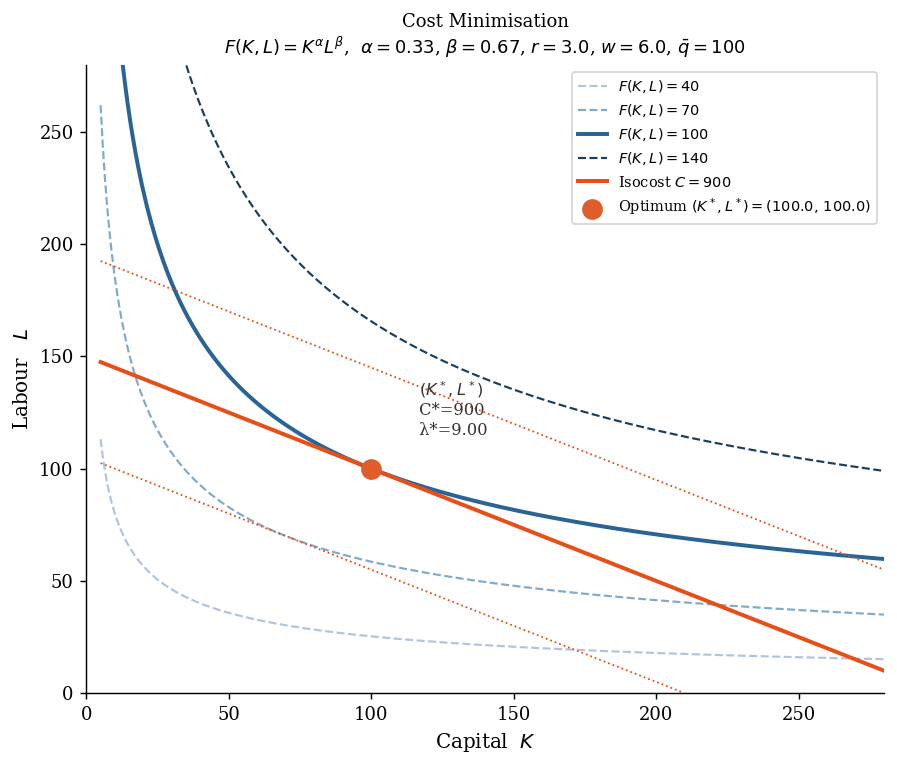

Figure saved → isoquant_isocost.png


In [ ]:
K_grid = np.linspace(5, 300, 400)

fig, ax = plt.subplots(figsize=(7, 6))

#  Isoquants for several output levels 
q_levels = [Q_BAR * f for f in (0.4, 0.7, 1.0, 1.4)]
colours  = ['#b0c4de', '#7faacc', '#2a6496', '#1a3f5e']

for q_lvl, col in zip(q_levels, colours):
    # L = (q / K^alpha)^(1/beta)
    L_iq = (q_lvl / K_grid**ALPHA) ** (1 / BETA)
    lw   = 2.2 if q_lvl == Q_BAR else 1.2
    ls   = '-'  if q_lvl == Q_BAR else '--'
    ax.plot(K_grid, L_iq, color=col, lw=lw, ls=ls,
            label=f'$F(K,L)={q_lvl:.0f}$')

#  Isocost lines 
cost_levels = [C_opt * f for f in (0.7, 1.0, 1.3)]
for c_lvl in cost_levels:
    # L = (C - rK) / w
    L_ic = (c_lvl - R * K_grid) / W
    mask = L_ic > 0
    lw   = 2.2 if c_lvl == C_opt else 1.0
    ax.plot(K_grid[mask], L_ic[mask], color="#e64f18", lw=lw,
            ls=('-' if c_lvl == C_opt else ':'),
            label=(f'Isocost $C={c_lvl:.0f}$' if c_lvl == C_opt else None))

#  Optimum point 
ax.scatter(K_opt, L_opt, s=110, color='#e05c2a', zorder=5,
           label=f'Optimum $(K^*,L^*)=({K_opt:.1f},\, {L_opt:.1f})$')
ax.annotate(f' $(K^*,L^*)$\n C*={C_opt:.0f}\n λ*={lam_opt:.2f}',
            xy=(K_opt, L_opt), xytext=(K_opt + 15, L_opt + 15),
            fontsize=9, color='#333')

ax.set_xlim(0, 280); ax.set_ylim(0, 280)
ax.set_xlabel('Capital  $K$', fontsize=11)
ax.set_ylabel('Labour   $L$', fontsize=11)
ax.set_title(f'Cost Minimisation\n'
             f'$F(K,L)=K^{{\\alpha}}L^{{\\beta}}$,  '
             f'$\\alpha={ALPHA:.2f}$, $\\beta={BETA:.2f}$, '
             f'$r={R}$, $w={W}$, $\\bar{{q}}={Q_BAR:.0f}$', fontsize=10)
ax.legend(fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.savefig('isoquant_isocost.png', dpi=150)
plt.show()
print("Figure saved → isoquant_isocost.png")


## 5 · Sensitivity Analysis — Shadow Price vs Output Target

The Lagrange multiplier $\lambda^*$ equals marginal cost $\partial C^*/\partial \bar{q}$.
Here we verify this numerically by varying $\bar{q}$ and plotting both
the minimum cost curve and the shadow price.

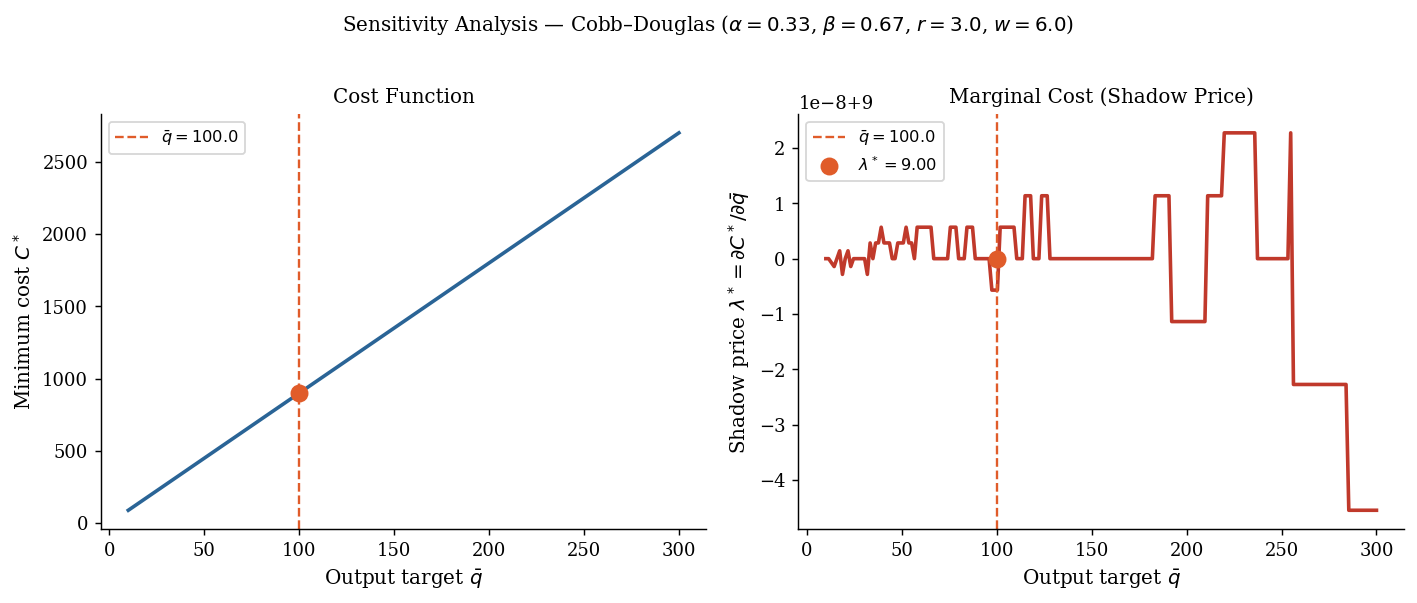

Figure saved → sensitivity_analysis.png


In [11]:
q_range = np.linspace(10, 300, 200)

# Vectorised closed-form expressions
def K_star_fn(q_val):
    return q_val * (ALPHA * W / (BETA * R)) ** BETA

def L_star_fn(q_val):
    return q_val * (BETA * R / (ALPHA * W)) ** ALPHA

def C_star_fn(q_val):
    return R * K_star_fn(q_val) + W * L_star_fn(q_val)

def lam_star_fn(q_val):
    """Shadow price = marginal cost = dC*/dq (numerical derivative)."""
    dq = 1e-5
    return (C_star_fn(q_val + dq) - C_star_fn(q_val - dq)) / (2 * dq)

C_vals   = C_star_fn(q_range)
lam_vals = lam_star_fn(q_range)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: minimum cost curve
axes[0].plot(q_range, C_vals, color='#2a6496', lw=2)
axes[0].axvline(Q_BAR, color='#e05c2a', ls='--', lw=1.3, label=f'$\\bar{{q}}={Q_BAR}$')
axes[0].scatter(Q_BAR, C_opt, color='#e05c2a', s=80, zorder=5)
axes[0].set_xlabel('Output target $\\bar{q}$', fontsize=11)
axes[0].set_ylabel('Minimum cost $C^*$', fontsize=11)
axes[0].set_title('Cost Function', fontsize=11)
axes[0].legend(fontsize=9)

# Right: shadow price (marginal cost)
axes[1].plot(q_range, lam_vals, color='#c0392b', lw=2)
axes[1].axvline(Q_BAR, color='#e05c2a', ls='--', lw=1.3, label=f'$\\bar{{q}}={Q_BAR}$')
axes[1].scatter(Q_BAR, lam_opt, color='#e05c2a', s=80, zorder=5,
                label=f'$\\lambda^*={lam_opt:.2f}$')
axes[1].set_xlabel('Output target $\\bar{q}$', fontsize=11)
axes[1].set_ylabel('Shadow price $\\lambda^* = \\partial C^*/\\partial \\bar{q}$', fontsize=11)
axes[1].set_title('Marginal Cost (Shadow Price)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle(f'Sensitivity Analysis — Cobb–Douglas '
             f'($\\alpha={ALPHA:.2f}$, $\\beta={BETA:.2f}$, $r={R}$, $w={W}$)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → sensitivity_analysis.png")

---
## 6 · Results Summary

In [12]:
MRTS     = (ALPHA / BETA) * (L_opt / K_opt)   # = F_K / F_L at optimum
price_ratio = R / W

print("═" * 52)
print("  COST MINIMISATION — RESULTS SUMMARY")
print("═" * 52)
print(f"  Production function : F(K,L) = K^{ALPHA:.2f} L^{BETA:.2f}")
print(f"  Input prices        : r = {R},  w = {W}")
print(f"  Output target       : q̄ = {Q_BAR}")
print("─" * 52)
print(f"  Optimal capital  K* = {K_opt:.4f}")
print(f"  Optimal labour   L* = {L_opt:.4f}")
print(f"  Minimum cost     C* = {C_opt:.4f}")
print(f"  Shadow price     λ* = {lam_opt:.4f}  (marginal cost)")
print("─" * 52)
print(f"  Optimality check    : MRTS = {MRTS:.4f}  |  r/w = {price_ratio:.4f}")
print(f"  MRTS = r/w ?        : {abs(MRTS - price_ratio) < 1e-8}")
print(f"  Constraint check    : F(K*,L*) = {output_chk:.4f}  (q̄ = {Q_BAR})")
print("═" * 52)

════════════════════════════════════════════════════
  COST MINIMISATION — RESULTS SUMMARY
════════════════════════════════════════════════════
  Production function : F(K,L) = K^0.33 L^0.67
  Input prices        : r = 3.0,  w = 6.0
  Output target       : q̄ = 100.0
────────────────────────────────────────────────────
  Optimal capital  K* = 100.0000
  Optimal labour   L* = 100.0000
  Minimum cost     C* = 900.0000
  Shadow price     λ* = 9.0000  (marginal cost)
────────────────────────────────────────────────────
  Optimality check    : MRTS = 0.5000  |  r/w = 0.5000
  MRTS = r/w ?        : True
  Constraint check    : F(K*,L*) = 100.0000  (q̄ = 100.0)
════════════════════════════════════════════════════
